In [165]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import joblib
from src.features import get_historical_tier_diff

target_map = {0.0:0, 0.5:1, 1: 2} #0 is away win, 1 is draw, 2 is home win


In [166]:
df = pd.read_csv('../data/world_cup_training_data.csv')
df['target'] = df['target'].map(target_map) #make sure the targets are distinct ints for future purposes

squad_values = {
    "Mexico": 226, "South Korea": 154, "South Africa": 50, "Czech Republic": 200,
    "Canada": 230, "Switzerland": 360, "Qatar": 23, "Bosnia and Herzegovina": 80,
    "Brazil": 1100, "Morocco": 350, "Haiti": 10, "Scotland": 200,
    "United States": 310, "Paraguay": 100, "Australia": 40, "Turkey": 320,
    "Germany": 850, "Curaçao": 5, "Ivory Coast": 300, "Ecuador": 230,
    "Netherlands": 600, "Japan": 290, "Sweden": 210, "Tunisia": 45,
    "Belgium": 450, "Egypt": 130, "Iran": 50, "New Zealand": 20,
    "Spain": 1000, "Cape Verde": 30, "Saudi Arabia": 30, "Uruguay": 480,
    "France": 1200, "Senegal": 250, "Iraq": 10, "Norway": 450,
    "Argentina": 800, "Algeria": 180, "Austria": 240, "Jordan": 15,
    "Portugal": 1050, "DR Congo": 110, "Uzbekistan": 35, "Colombia": 280,
    "England": 1500, "Croatia": 300, "Ghana": 200, "Panama": 20
}

df['home_value'] = df['home_team'].map(lambda x: squad_values.get(x, 20))
df['away_value'] = df['away_team'].map(lambda x: squad_values.get(x, 20))


df['squad_value_diff'] = df.apply(get_historical_tier_diff, axis=1, args=(squad_values,))

#Setting up testing and training dataframes
training_set = df[df['date'] <= '2024-12-31']
test_set = df[(df['date'] > '2024-12-31') & (df['date'] < '2026-06-11')]

In [167]:
features = ['elo_diff', 'home_elo', 'away_elo', 'home_form', 'away_form', 'h2h', 'home_gd', 'away_gd', 'squad_value_diff']
X_train = training_set[features]
y = training_set['target']

z = StandardScaler()
X_scaled = z.fit_transform(X_train)
lr_model = LogisticRegression()
lr_model.fit(X_scaled, y)

xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train, y)

joblib.dump(z, 'scaler.joblib')

['scaler.joblib']

In [168]:
X_test = test_set[features]
y_test = test_set['target']

X_test_scaled = z.transform(X_test)

lr_preds = lr_model.predict(X_test_scaled)
xgb_preds = xgb_model.predict(X_test)

#See who is more accurate
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_preds):.2%}")
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.2%}")

print(test_set)


Logistic Regression Accuracy: 62.22%
XGBoost Accuracy: 61.65%
             date     home_team               away_team  home_elo  away_elo  \
48090  2025-01-02       Vietnam                Thailand   1444.83   1567.86   
48091  2025-01-03      Zanzibar                Tanzania   1510.50   1530.45   
48092  2025-01-04  Burkina Faso                   Kenya   1609.54   1482.61   
48093  2025-01-04          Oman                 Bahrain   1643.37   1618.80   
48094  2025-01-05      Thailand                 Vietnam   1551.86   1460.83   
...           ...           ...                     ...       ...       ...   
49300  2026-06-03     Gibraltar  British Virgin Islands   1107.69   1014.29   
49301  2026-06-03      DR Congo                 Denmark   1767.45   1924.97   
49302  2026-06-03       Albania                  Israel   1701.97   1685.23   
49303  2026-06-03   South Korea             El Salvador   1876.11   1501.91   
49304  2026-06-03   Philippines                    Guam   1326.80    

Since XGBoost is slightly more accurate at predicting results we will use it going forward

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

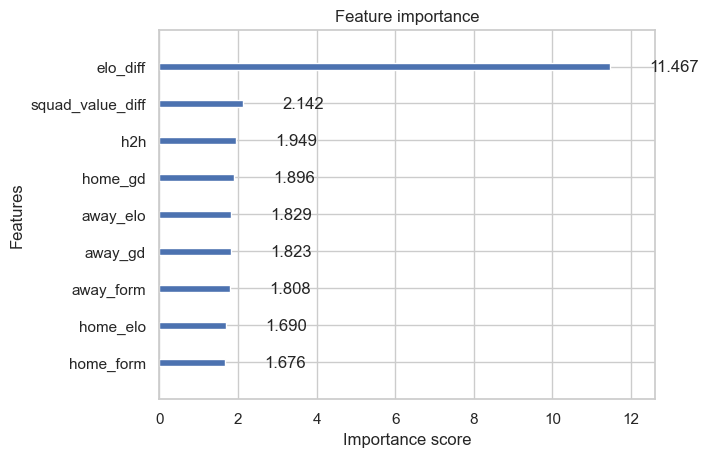

In [169]:
#Finding the MVP
importance_score = xgb_model.get_booster().get_score(importance_type='gain')
xgb.plot_importance(xgb_model, importance_type='gain', values_format='{v:.3f}')


Model values the difference in elo as the most important factor when determining outcome, all other factors have around the same impact which is drastically less than elo_diff

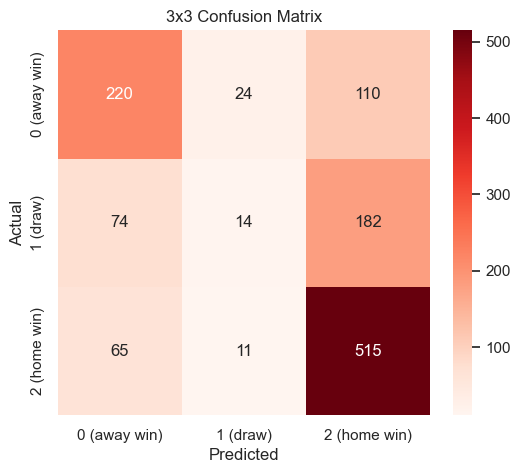

In [170]:
cm = confusion_matrix(y_test, xgb_preds, labels=[0,1,2]) #Confusion matrix

#Displaying the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['0 (away win)', '1 (draw)', '2 (home win)'], 
            yticklabels=['0 (away win)', '1 (draw)', '2 (home win)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('3x3 Confusion Matrix')
plt.show()

The model does not predict draws very often, which is a big problem due to draws being a possibility in the WC. As a result, we must fix this issue to assure more reliable predictions for the wc.

To fix this we must find a confidence threshold so where the absolute value of P(Home_Win) - P(Away_win) < draw intevral we return a draw

In [171]:
#Find confidence threshold

probabilites = xgb_model.predict_proba(X_test) #2D array containg the probability of home win, draw, and away win for each match

home, away = probabilites[:, 0], probabilites[:, 2]
diff = np.abs(home - away) #The difference between the probability of a home win vs an away win

#Get a dataframe with all the information to see at what percent_difference the model fails to predict
new = X_test.copy()

new['target'] = y_test.values
new['diff'] = diff
new['predicted'] = xgb_preds    
new['success'] = (new['target'] == new['predicted']).astype(int) #Boolean to see if model predicted correctly

wrong_preds = new[new['success'] == 0] #Dataframe containing all the wrong predictions
confidence_threshold = wrong_preds['diff'].mean()

wrong_preds_draws = wrong_preds[wrong_preds['target'] == 1]
draw_threshold = wrong_preds_draws['diff'].mean()

print("Draw threshold: ", draw_threshold)

Draw threshold:  0.3691787


         elo_diff     home_elo     away_elo   home_form   away_form  \
count  256.000000   256.000000   256.000000  256.000000  256.000000   
mean    14.976992  1629.598203  1614.621289    1.518750    1.435156   
std    194.168498   249.759434   252.975821    0.617173    0.586460   
min   -528.550000   881.470000   924.250000    0.000000    0.100000   
25%   -108.517500  1474.042500  1466.077500    1.100000    1.000000   
50%     19.320000  1640.070000  1626.865000    1.500000    1.400000   
75%    144.665000  1800.102500  1782.805000    2.000000    1.800000   
max    601.120000  2247.390000  2233.180000    3.000000    3.000000   

              h2h     home_gd     away_gd  squad_value_diff  target  \
count  256.000000  256.000000  256.000000        256.000000   256.0   
mean     0.498750    0.284375    0.144922          0.045260     1.0   
std      0.240051    1.084973    1.023208          1.254987     0.0   
min      0.000000   -3.900000   -2.700000         -4.046387     1.0   
25%  

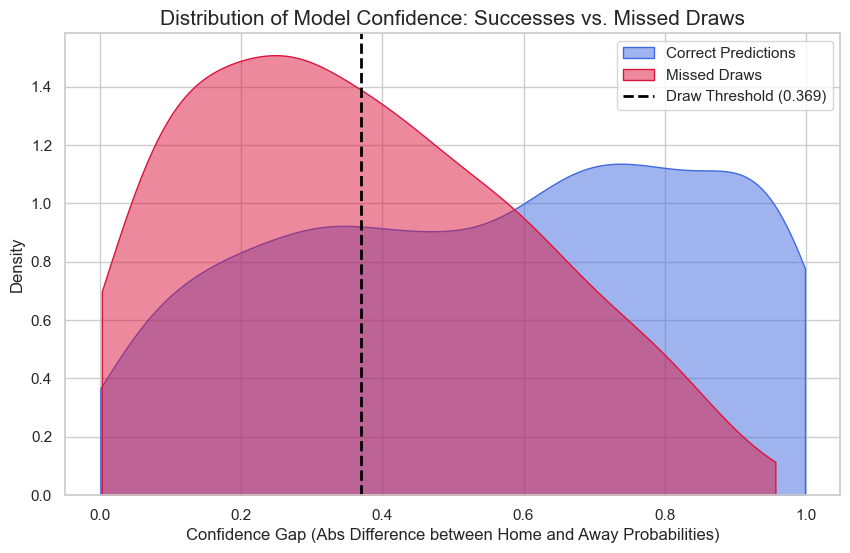

In [172]:
print(wrong_preds_draws.describe())

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.kdeplot(data=new[new['success'] == 1], x='diff', 
            fill=True, label='Correct Predictions', color='royalblue', alpha=0.5, cut = 0)

sns.kdeplot(data=wrong_preds_draws, x='diff', 
            fill=True, label='Missed Draws', color='crimson', alpha=0.5, cut = 0)

plt.axvline(x=draw_threshold, color='black', linestyle='--', linewidth=2, 
            label=f'Draw Threshold ({draw_threshold:.3f})')

plt.title('Distribution of Model Confidence: Successes vs. Missed Draws', fontsize=15)
plt.xlabel('Confidence Gap (Abs Difference between Home and Away Probabilities)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()

plt.show()

The graph compares the distribution of the confidence gap between the correct predictions and the missed draws. due to the missed draws distribution being skewed left we can infer that that most of the missed draws occur when the model is unsure about a clear winner is essentially guessing.

The dotted line represents the draw thereshold, moving foreward if the model has a confidence rating below .369 it will predict a draw. 

In [173]:
joblib.dump(xgb_model, 'world_cup_model.joblib')
joblib.dump(draw_threshold, 'draw_threshold.joblib')

['draw_threshold.joblib']

In [174]:
#Make a regressor to predict goal counts

y_home_goals = training_set['home_score']
y_away_goals = training_set['away_score']

model_home_goals = xgb.XGBRegressor(objective='count:poisson', n_estimators=100)
model_away_goals = xgb.XGBRegressor(objective='count:poisson', n_estimators=100)

model_home_goals.fit(X_train, y_home_goals)
model_away_goals.fit(X_train, y_away_goals)

joblib.dump(model_home_goals, 'home_goals_model.joblib')
joblib.dump(model_away_goals, 'away_goals_model.joblib')

['away_goals_model.joblib']